# Data Exploration and Dataset Splitting

In this notebook, we explore the processed peptide-HLA dataset and create a proper train/validation/test split.

The goal is to:
- understand the dataset structure
- check label distribution
- create a leakage-free split based on peptide sequences
- prepare Dataset A for model training

We ensure that the same peptide does not appear in both training and testing sets.

In [1]:
import pandas as pd
import numpy as np
from sklearn.model_selection import GroupShuffleSplit

## Dataset A - Global peptide + HLA Features

In [2]:

df = pd.read_csv("../data/features/processed_data_with_global_features.csv")

df.head()

,index,peptide,HLA,Label,hla_sequence,Peptide_AF1,Peptide_AF2,Peptide_AF3,Peptide_AF4,Peptide_AF5,...,HLA_Z4,HLA_Z5,HLA_boman,HLA_hydrophobicity,HLA_charge,HLA_molecular_weight,HLA_aliphatic_index,HLA_instability_index,HLA_isoelectric_point,HLA_mz
0,0,KEHVFFSEY,HLA-B*44:02,0,YYTKYREISTNTYENTAYIRYDDYTWAVDAYLSY,0.173955,-0.346010,0.376536,-0.138244,-0.186528,...,-0.595294,-0.155882,2.435294,-0.961765,-2.005081,4276.59504,51.764706,-11.114706,4.229102,2137.978906
1,1,DEGATLYRF,HLA-B*44:02,0,YYTKYREISTNTYENTAYIRYDDYTWAVDAYLSY,0.130313,-0.141878,0.624118,0.427633,0.340208,...,-0.595294,-0.155882,2.435294,-0.961765,-2.005081,4276.59504,51.764706,-11.114706,4.229102,2137.978906
2,2,TLAARIKFL,HLA-A*02:01,0,YFAMYGEKVAHTHVDTLYVRYHYYTWAVLAYTWY,-0.236566,-0.667240,0.421759,0.748899,0.552450,...,0.214706,-0.317941,0.506176,-0.120588,0.265832,4282.84454,68.823529,-4.388235,7.749856,2141.021991
3,3,KETLNEYKQL,HLA-B*44:02,0,YYTKYREISTNTYENTAYIRYDDYTWAVDAYLSY,0.644379,-0.419675,0.461561,0.160180,0.170256,...,-0.595294,-0.155882,2.435294,-0.961765,-2.005081,4276.59504,51.764706,-11.114706,4.229102,2137.978906
4,4,STTDAEACY,HLA-A*01:01,0,YFAMYQENMAHTDANTLYIIYRDYTWVARVYRGY,-0.016626,-0.045450,-0.193642,0.402509,-0.348259,...,-0.101471,-0.141471,1.769118,-0.447059,0.085599,4259.78264,63.235294,-7.820588,7.501996,2129.501106


## Dataset Overview

We first inspect the dataset size, columns, and general structure.

In [3]:
print("Shape:", df.shape)
df.columns

Shape: (8968, 225)


Index(['index', 'peptide', 'HLA', 'Label', 'hla_sequence', 'Peptide_AF1',
       'Peptide_AF2', 'Peptide_AF3', 'Peptide_AF4', 'Peptide_AF5',
       ...
       'HLA_Z4', 'HLA_Z5', 'HLA_boman', 'HLA_hydrophobicity', 'HLA_charge',
       'HLA_molecular_weight', 'HLA_aliphatic_index', 'HLA_instability_index',
       'HLA_isoelectric_point', 'HLA_mz'],
      dtype='object', length=225)

## Label Distribution

We check how balanced the dataset is between immunogenic (1) and non-immunogenic (0) samples.

In [4]:
df["Label"].value_counts()

Label
0    4912
1    4056
Name: count, dtype: int64

In [5]:
df["Label"].value_counts(normalize=True)

Label
0    0.547725
1    0.452275
Name: proportion, dtype: float64

## Peptide Analysis

We examine how many unique peptides are present and whether duplicates exist.

In [6]:
print("Total samples:", len(df))
print("Unique peptides:", df["peptide"].nunique())

Total samples: 8968
Unique peptides: 8380


## Train/Test Split Strategy

To avoid data leakage, we split the dataset based on peptide sequences.

This ensures that:
- the same peptide does not appear in both training and testing sets
- the model does not memorize peptide-specific patterns

In [7]:
from sklearn.model_selection import GroupShuffleSplit

groups = df["peptide"]
y = df["Label"]

gss = GroupShuffleSplit(test_size=0.2, random_state=42)

train_idx, test_idx = next(gss.split(df, y, groups))

train_df = df.iloc[train_idx]
test_df = df.iloc[test_idx]

print("Train size:", train_df.shape)
print("Test size:", test_df.shape)

Train size: (7153, 225)
Test size: (1815, 225)


## Leakage Check

We verify that no peptide appears in both training and testing sets.

In [8]:
train_peptides = set(train_df["peptide"])
test_peptides = set(test_df["peptide"])

overlap = train_peptides.intersection(test_peptides)
print("Number of overlapping peptides:", len(overlap))

Number of overlapping peptides: 0


## Validation Split

We further split the training data into training and validation sets using the same grouping strategy.

In [9]:
gss_val = GroupShuffleSplit(test_size=0.2, random_state=42)

train_idx2, val_idx2 = next(
    gss_val.split(train_df, train_df["Label"], groups=train_df["peptide"])
)

train_final = train_df.iloc[train_idx2]
val_df = train_df.iloc[val_idx2]

# map back to ORIGINAL full-dataframe indices
train_idx_final = train_df.index[train_idx2].to_numpy()
val_idx_final = train_df.index[val_idx2].to_numpy()

print("Final train size:", train_final.shape)
print("Validation size:", val_df.shape)

Final train size: (5707, 225)
Validation size: (1446, 225)


## Final Label Distribution

We check that the label distribution is similar across splits.

In [10]:
print("Train:")
print(train_final["Label"].value_counts(normalize=True))

print("\nValidation:")
print(val_df["Label"].value_counts(normalize=True))

print("\nTest:")
print(test_df["Label"].value_counts(normalize=True))

Train:
Label
0    0.550727
1    0.449273
Name: proportion, dtype: float64

Validation:
Label
0    0.538036
1    0.461964
Name: proportion, dtype: float64

Test:
Label
0    0.546006
1    0.453994
Name: proportion, dtype: float64


In [42]:
train_final.to_csv("../data/dataset_A_train.csv", index=False)
val_df.to_csv("../data/dataset_A_val.csv", index=False)
test_df.to_csv("../data/dataset_A_test.csv", index=False)

In [43]:
# save indices for later to use on other versions of datasets with different features
# in order to explore other feature methods (LLM embeddings or other packages to extract features)

np.save("../data/splits/train_idx.npy", train_idx_final)
np.save("../data/splits/val_idx.npy", val_idx_final)
np.save("../data/splits/test_idx.npy", test_idx)

## Dataset B - Local position specific peptide features + HLA Global Features

In [45]:
df_B = pd.read_csv("../data/features/processed_data_with_position_specific_features.csv")
df_B.head()

,index,peptide,HLA,Label,hla_sequence,PeptidePos_p1_f1,PeptidePos_p1_f2,PeptidePos_p1_f3,PeptidePos_p1_f4,PeptidePos_p1_f5,...,HLA_Z4,HLA_Z5,HLA_boman,HLA_hydrophobicity,HLA_charge,HLA_molecular_weight,HLA_aliphatic_index,HLA_instability_index,HLA_isoelectric_point,HLA_mz
0,0,KEHVFFSEY,HLA-B*44:02,0,YYTKYREISTNTYENTAYIRYDDYTWAVDAYLSY,0.0,0.0,0.995649,0.006811,0.0,...,-0.595294,-0.155882,2.435294,-0.961765,-2.005081,4276.59504,51.764706,-11.114706,4.229102,2137.978906
1,1,DEGATLYRF,HLA-B*44:02,0,YYTKYREISTNTYENTAYIRYDDYTWAVDAYLSY,0.0,0.0,-1.003625,-0.007540,0.0,...,-0.595294,-0.155882,2.435294,-0.961765,-2.005081,4276.59504,51.764706,-11.114706,4.229102,2137.978906
2,2,TLAARIKFL,HLA-A*02:01,0,YFAMYGEKVAHTHVDTLYVRYHYYTWAVLAYTWY,0.0,0.0,-0.004137,-0.000035,0.0,...,0.214706,-0.317941,0.506176,-0.120588,0.265832,4282.84454,68.823529,-4.388235,7.749856,2141.021991
3,3,KETLNEYKQL,HLA-B*44:02,0,YYTKYREISTNTYENTAYIRYDDYTWAVDAYLSY,0.0,0.0,0.995649,0.006811,0.0,...,-0.595294,-0.155882,2.435294,-0.961765,-2.005081,4276.59504,51.764706,-11.114706,4.229102,2137.978906
4,4,STTDAEACY,HLA-A*01:01,0,YFAMYQENMAHTDANTLYIIYRDYTWVARVYRGY,0.0,0.0,-0.004137,-0.000039,0.0,...,-0.101471,-0.141471,1.769118,-0.447059,0.085599,4259.78264,63.235294,-7.820588,7.501996,2129.501106


In [ ]:
# from A
train_idx = np.load("../data/splits/train_idx.npy")
val_idx   = np.load("../data/splits/val_idx.npy")
test_idx  = np.load("../data/splits/test_idx.npy")

In [47]:
# sanity check to ensure that the splits are consistent with the new dataset B

train_idx = np.load("../data/splits/train_idx.npy")
val_idx   = np.load("../data/splits/val_idx.npy")
test_idx  = np.load("../data/splits/test_idx.npy")

print("Total indices:", len(train_idx) + len(val_idx) + len(test_idx))
print("Dataset B size:", len(df_B))

Total indices: 8968
Dataset B size: 8968


In [48]:
# check no overlap between splits
print("Train ∩ Val:", len(set(train_idx).intersection(set(val_idx))))
print("Train ∩ Test:", len(set(train_idx).intersection(set(test_idx))))
print("Val ∩ Test:", len(set(val_idx).intersection(set(test_idx))))

Train ∩ Val: 0
Train ∩ Test: 0
Val ∩ Test: 0


In [49]:
max_index = max(max(train_idx), max(val_idx), max(test_idx))

print("Max index in splits:", max_index)
print("Dataset B max index:", len(df_B) - 1)

Max index in splits: 8967
Dataset B max index: 8967


In [50]:
# apply same splits to dataset B
train_df = df_B.iloc[train_idx]
val_df   = df_B.iloc[val_idx]
test_df  = df_B.iloc[test_idx]

train_df.to_csv("../data/dataset_B_train.csv", index=False)
val_df.to_csv("../data/dataset_B_val.csv", index=False)
test_df.to_csv("../data/dataset_B_test.csv", index=False)

## Dataset C

In [23]:
df_C = pd.read_csv("../data/processed_data_with_pHLA_position_specific_features.csv")
df_C.head()

,index,peptide,HLA,Label,hla_sequence,PeptidePos_p1_f1,PeptidePos_p1_f2,PeptidePos_p1_f3,PeptidePos_p1_f4,PeptidePos_p1_f5,...,HLApos_PeptidePos_p34_f9,HLApos_PeptidePos_p34_f10,HLApos_PeptidePos_p34_f11,HLApos_PeptidePos_p34_f12,HLApos_PeptidePos_p34_f13,HLApos_PeptidePos_p34_f14,HLApos_PeptidePos_p34_f15,HLApos_PeptidePos_p34_f16,HLApos_PeptidePos_p34_f17,HLApos_PeptidePos_p34_f18
0,0,KEHVFFSEY,HLA-B*44:02,0,YYTKYREISTNTYENTAYIRYDDYTWAVDAYLSY,0.0,0.0,0.995649,0.006811,0.0,...,1.0,3.0,0.0,0.0,181.19,3.0,4.0,83.6,2.3,3.0
1,1,DEGATLYRF,HLA-B*44:02,0,YYTKYREISTNTYENTAYIRYDDYTWAVDAYLSY,0.0,0.0,-1.003625,-0.007540,0.0,...,1.0,3.0,0.0,0.0,181.19,3.0,4.0,83.6,2.3,3.0
2,2,TLAARIKFL,HLA-A*02:01,0,YFAMYGEKVAHTHVDTLYVRYHYYTWAVLAYTWY,0.0,0.0,-0.004137,-0.000035,0.0,...,1.0,3.0,0.0,0.0,181.19,3.0,4.0,83.6,2.3,3.0
3,3,KETLNEYKQL,HLA-B*44:02,0,YYTKYREISTNTYENTAYIRYDDYTWAVDAYLSY,0.0,0.0,0.995649,0.006811,0.0,...,1.0,3.0,0.0,0.0,181.19,3.0,4.0,83.6,2.3,3.0
4,4,STTDAEACY,HLA-A*01:01,0,YFAMYQENMAHTDANTLYIIYRDYTWVARVYRGY,0.0,0.0,-0.004137,-0.000039,0.0,...,1.0,3.0,0.0,0.0,181.19,3.0,4.0,83.6,2.3,3.0


In [25]:
# apply same splits to dataset B
train_df = df_C.iloc[train_idx]
val_df   = df_C.iloc[val_idx]
test_df  = df_C.iloc[test_idx]

train_df.to_csv("../data/dataset_C_train.csv", index=False)
val_df.to_csv("../data/dataset_C_val.csv", index=False)
test_df.to_csv("../data/dataset_C_test.csv", index=False)

In [26]:
train_df

,index,peptide,HLA,Label,hla_sequence,PeptidePos_p1_f1,PeptidePos_p1_f2,PeptidePos_p1_f3,PeptidePos_p1_f4,PeptidePos_p1_f5,...,HLApos_PeptidePos_p34_f9,HLApos_PeptidePos_p34_f10,HLApos_PeptidePos_p34_f11,HLApos_PeptidePos_p34_f12,HLApos_PeptidePos_p34_f13,HLApos_PeptidePos_p34_f14,HLApos_PeptidePos_p34_f15,HLApos_PeptidePos_p34_f16,HLApos_PeptidePos_p34_f17,HLApos_PeptidePos_p34_f18
0,0,KEHVFFSEY,HLA-B*44:02,0,YYTKYREISTNTYENTAYIRYDDYTWAVDAYLSY,0.0,0.0,0.995649,0.006811,0.0,...,1.0,3.0,0.0,0.0,181.19,3.0,4.0,83.6,2.3,3.0
1,1,DEGATLYRF,HLA-B*44:02,0,YYTKYREISTNTYENTAYIRYDDYTWAVDAYLSY,0.0,0.0,-1.003625,-0.007540,0.0,...,1.0,3.0,0.0,0.0,181.19,3.0,4.0,83.6,2.3,3.0
2,2,TLAARIKFL,HLA-A*02:01,0,YFAMYGEKVAHTHVDTLYVRYHYYTWAVLAYTWY,0.0,0.0,-0.004137,-0.000035,0.0,...,1.0,3.0,0.0,0.0,181.19,3.0,4.0,83.6,2.3,3.0
3,3,KETLNEYKQL,HLA-B*44:02,0,YYTKYREISTNTYENTAYIRYDDYTWAVDAYLSY,0.0,0.0,0.995649,0.006811,0.0,...,1.0,3.0,0.0,0.0,181.19,3.0,4.0,83.6,2.3,3.0
4,4,STTDAEACY,HLA-A*01:01,0,YFAMYQENMAHTDANTLYIIYRDYTWVARVYRGY,0.0,0.0,-0.004137,-0.000039,0.0,...,1.0,3.0,0.0,0.0,181.19,3.0,4.0,83.6,2.3,3.0
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
8958,8961,VMLLVHYAI,HLA-A*24:02,1,YSAMYEEKVAHTDENIAYLMFHYYTWAVQAYTGY,290.0,0.0,-0.004137,-0.000035,1.0,...,1.0,3.0,0.0,0.0,181.19,3.0,4.0,83.6,2.3,3.0
8961,8964,GLFGGLNWI,HLA-A*02:01,1,YFAMYGEKVAHTHVDTLYVRYHYYTWAVLAYTWY,0.0,0.0,-0.004137,-0.000055,0.0,...,1.0,3.0,0.0,0.0,181.19,3.0,4.0,83.6,2.3,3.0
8963,8966,YYMATLKNV,HLA-A*24:02,1,YSAMYEEKVAHTDENIAYLMFHYYTWAVQAYTGY,0.0,1.0,-0.004931,-0.000027,0.0,...,1.0,3.0,0.0,0.0,181.19,3.0,4.0,83.6,2.3,3.0
8964,8967,ILMNDQEVGV,HLA-A*02:01,1,YFAMYGEKVAHTHVDTLYVRYHYYTWAVLAYTWY,390.0,0.0,-0.004137,-0.000032,1.0,...,1.0,3.0,0.0,0.0,181.19,3.0,4.0,83.6,2.3,3.0


# Data Analysis

In [19]:
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
import numpy as np


In [32]:
df = pd.read_csv("../data/features/processed_data_with_global_features.csv")

print(df.shape)
print(df.columns)
print(df.head())

(8968, 225)
Index(['index', 'peptide', 'HLA', 'Label', 'hla_sequence', 'Peptide_AF1',
       'Peptide_AF2', 'Peptide_AF3', 'Peptide_AF4', 'Peptide_AF5',
       ...
       'HLA_Z4', 'HLA_Z5', 'HLA_boman', 'HLA_hydrophobicity', 'HLA_charge',
       'HLA_molecular_weight', 'HLA_aliphatic_index', 'HLA_instability_index',
       'HLA_isoelectric_point', 'HLA_mz'],
      dtype='object', length=225)
   index     peptide          HLA  Label                        hla_sequence  \
0      0   KEHVFFSEY  HLA-B*44:02      0  YYTKYREISTNTYENTAYIRYDDYTWAVDAYLSY   
1      1   DEGATLYRF  HLA-B*44:02      0  YYTKYREISTNTYENTAYIRYDDYTWAVDAYLSY   
2      2   TLAARIKFL  HLA-A*02:01      0  YFAMYGEKVAHTHVDTLYVRYHYYTWAVLAYTWY   
3      3  KETLNEYKQL  HLA-B*44:02      0  YYTKYREISTNTYENTAYIRYDDYTWAVDAYLSY   
4      4   STTDAEACY  HLA-A*01:01      0  YFAMYQENMAHTDANTLYIIYRDYTWVARVYRGY   

   Peptide_AF1  Peptide_AF2  Peptide_AF3  Peptide_AF4  Peptide_AF5  ...  \
0     0.173955    -0.346010     0.376536    -0.1

count    8968.000000
mean        9.277542
std         0.447811
min         9.000000
25%         9.000000
50%         9.000000
75%        10.000000
max        10.000000
Name: peptide_length, dtype: float64


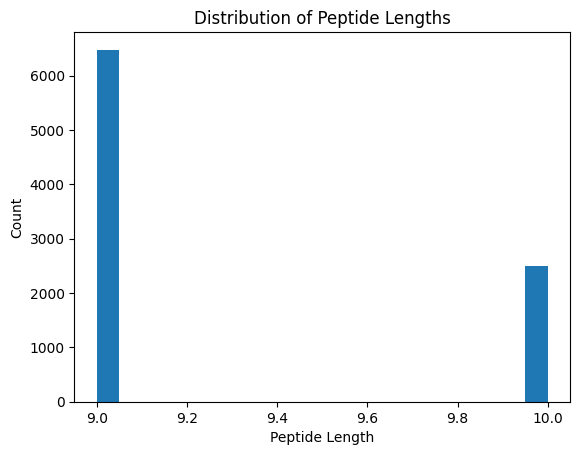

In [33]:
df["peptide_length"] = df["peptide"].apply(len)

print(df["peptide_length"].describe())

plt.hist(df["peptide_length"], bins=20)
plt.xlabel("Peptide Length")
plt.ylabel("Count")
plt.title("Distribution of Peptide Lengths")
plt.show()

Number of unique HLAs: 104
HLA
HLA-A*02:01    3300
HLA-A*24:02    1452
HLA-B*44:02     901
HLA-A*01:01     879
HLA-B*07:02     478
HLA-A*11:01     235
HLA-B*08:01     193
HLA-A*03:01     155
HLA-B*35:01     155
HLA-A*02:02     127
Name: count, dtype: int64


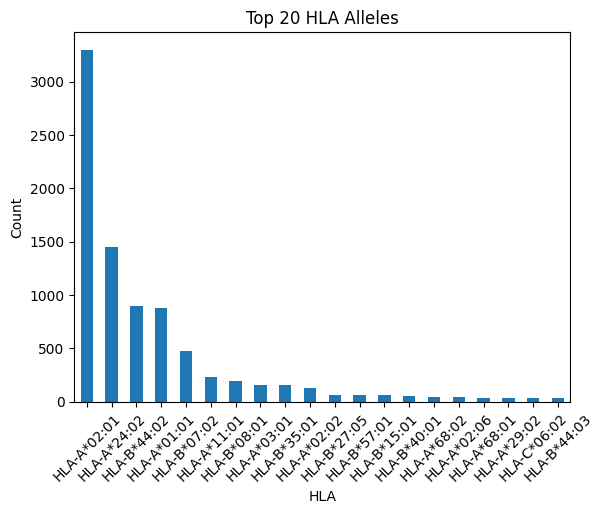

In [34]:
print("Number of unique HLAs:", df["HLA"].nunique())

hla_counts = df["HLA"].value_counts()

print(hla_counts.head(10))

# plot top 20
hla_counts.head(20).plot(kind="bar")
plt.title("Top 20 HLA Alleles")
plt.ylabel("Count")
plt.xticks(rotation=45)
plt.show()

Label
0    0.547725
1    0.452275
Name: proportion, dtype: float64


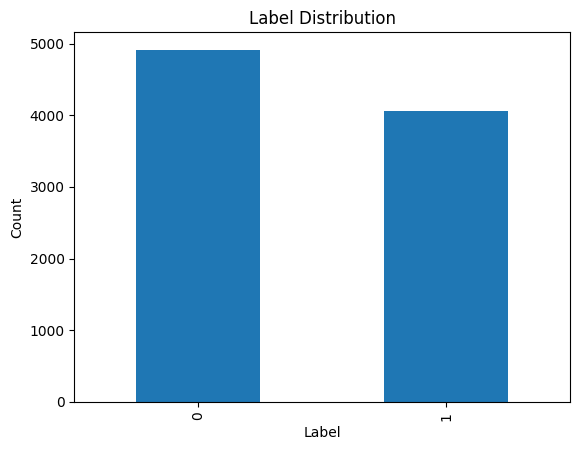

In [35]:
label_counts = df["Label"].value_counts(normalize=True)
print(label_counts)

df["Label"].value_counts().plot(kind="bar")
plt.title("Label Distribution")
plt.xlabel("Label")
plt.ylabel("Count")
plt.show()